China. It's not even close — China produces around 45,000 kt of rare earth elements in 2024, which is roughly 60% of global supply. Myanmar is second but far behind.
This is actually one of the most important geopolitical facts in the entire dataset. The world's clean energy future — wind turbines, EV motors, electronics — all depend on magnets made from rare earths, and China controls the majority of supply.
That's the kind of insight that makes a LinkedIn post genuinely interesting. Not just "here's a chart" but "here's what this data is actually telling us about the world."
Now you have your three insights for the LinkedIn post:

Copper demand will grow massively by 2040, driven by electricity networks
China controls rare earth supply — a critical dependency for clean energy
Electric vehicles are the most mineral-hungry technology by far

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import pandas as pd

file = 'Critical Minerals Dataset.xlsx'

supply = pd.read_excel(file, sheet_name='2 Total supply for key minerals')

print(supply.shape)
print(supply.head(15))

(68, 11)
                                           Unnamed: 0    Unnamed: 1  \
0   Total supply for key energy transition mineral...           NaN   
1                                                 NaN           NaN   
2                                                 NaN   2024.000000   
3                                                 NaN           NaN   
4                                     Copper - Mining           NaN   
5                                               Chile   5476.000000   
6                        Democratic Republic of Congo   2876.000000   
7                                                Peru   2631.000000   
8                                               China   1815.000000   
9                                              Russia   1101.000000   
10                                      United States   1138.000000   
11                                      Rest of world   7757.000000   
12                                              Total  22794.000000 

In [6]:
file = 'Critical Minerals Dataset.xlsx'
raw = pd.read_excel(file, sheet_name='2 Total supply for key minerals', header=None)

print(raw.iloc[:, 0:5].to_string())

                                                                                                                                                                                  0             1             2             3             4
0                                                                                                                                                                               NaN           NaN           NaN           NaN           NaN
1                                                                                                                   Total supply for key energy transition minerals, base case (kt)           NaN           NaN           NaN           NaN
2                                                                                                                                                                               NaN           NaN           NaN           NaN           NaN
3                                                       

In [7]:
raw = pd.read_excel(file, sheet_name='2 Total supply for key minerals', header=None)

# Give columns proper names
raw.columns = ['country', '2024', '2030', '2035', '2040',
               'gap', 'mineral2', '2024b', '2030b', '2035b', '2040b']

# Keep only the left block (mining)
mining = raw[['country', '2024', '2030', '2035', '2040']].copy()

# Drop rows where country is NaN
mining = mining.dropna(subset=['country'])

# Drop rows that are titles, totals, notes or top 3 share
remove = ['Total', 'Top 3 share', 'Notes:', '"Base case"']
mask = mining['country'].str.startswith(tuple(remove), na=False)
mining = mining[~mask]

# Drop the mineral header rows (they have NaN in 2024 column)
mining = mining.dropna(subset=['2024'])

# Add a mineral column by forward filling
raw2 = raw[['country', '2024']].copy()
raw2.columns = ['country', 'val']
mineral_rows = raw2[raw2['val'].isna() & raw2['country'].notna()]['country'].tolist()
print("Mineral headers found:", mineral_rows)

Mineral headers found: ['Total supply for key energy transition minerals, base case (kt)', 'Copper - Mining', 'Cobalt - Mining', 'Lithium - Mining', 'Nickel - Mining', 'Graphite - Mining (natural)', 'Magnet rare earth elements - Mining', 'Notes: Supply projections for the key energy transition minerals are built using the data for the pipeline of operating and announced mining and refining projects by country. ', '“Base case” is assessed through their probability of coming online based on various factors such as the status of financing, permitting and feasibility studies.']


In [8]:
raw = pd.read_excel(file, sheet_name='2 Total supply for key minerals', header=None)

raw.columns = ['country', '2024', '2030', '2035', '2040',
               'gap', 'mineral2', '2024b', '2030b', '2035b', '2040b']

minerals = [
    'Copper - Mining', 'Cobalt - Mining', 'Lithium - Mining',
    'Nickel - Mining', 'Graphite - Mining (natural)',
    'Magnet rare earth elements - Mining'
]

remove = ['Total', 'Top 3 share', 'Notes:', '"Base case"', 
          'Total supply']

rows = []
current_mineral = None

for _, row in raw.iterrows():
    country = row['country']
    
    # If this row is a mineral header, remember it
    if country in minerals:
        current_mineral = country
        continue
    
    # Skip empty, totals, notes
    if pd.isna(country):
        continue
    if any(str(country).startswith(r) for r in remove):
        continue
    
    # Skip rows with no 2024 value
    if pd.isna(row['2024']):
        continue
    
    # This is a real country row — add it
    rows.append({
        'mineral': current_mineral,
        'country': country,
        '2024': int(row['2024']),
        '2030': int(row['2030']),
        '2035': int(row['2035']),
        '2040': int(row['2040'])
    })

df = pd.DataFrame(rows)
print(df.shape)
print(df)

(37, 6)
                                mineral                       country  2024  \
0                       Copper - Mining                         Chile  5476   
1                       Copper - Mining  Democratic Republic of Congo  2876   
2                       Copper - Mining                          Peru  2631   
3                       Copper - Mining                         China  1815   
4                       Copper - Mining                        Russia  1101   
5                       Copper - Mining                 United States  1138   
6                       Copper - Mining                 Rest of world  7757   
7                       Cobalt - Mining  Democratic Republic of Congo   181   
8                       Cobalt - Mining                     Indonesia    33   
9                       Cobalt - Mining                        Russia     6   
10                      Cobalt - Mining                     Australia     6   
11                      Cobalt - Mining     

In [9]:
# Check every mineral is there
print(df['mineral'].value_counts())

# Check for any missing values
print("\nMissing values:")
print(df.isnull().sum())

# Save to a clean CSV
df.to_csv('minerals_clean.csv', index=False)
print("\nSaved!")

mineral
Copper - Mining                        7
Nickel - Mining                        7
Graphite - Mining (natural)            7
Lithium - Mining                       6
Cobalt - Mining                        5
Magnet rare earth elements - Mining    5
Name: count, dtype: int64

Missing values:
mineral    0
country    0
2024       0
2030       0
2035       0
2040       0
dtype: int64

Saved!


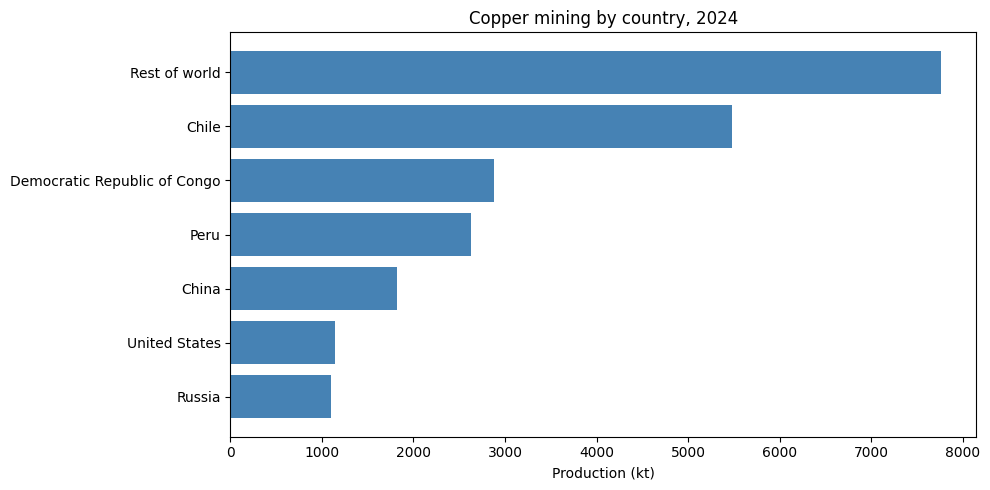

In [10]:
import matplotlib.pyplot as plt

copper = df[df['mineral'] == 'Copper - Mining'].copy()
copper = copper.sort_values('2024', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(copper['country'], copper['2024'], color='steelblue')
plt.xlabel('Production (kt)')
plt.title('Copper mining by country, 2024')
plt.tight_layout()
plt.show()

In [11]:
raw2 = pd.read_excel(file, sheet_name='1 Total demand for key minerals', header=None)

print(raw2.shape)
print(raw2.iloc[:, 0:6].to_string())

(71, 20)
                                                                                                                                                                                                                                                                             0             1   2                         3             4             5
0                                                                                                                                                                                                                                                                          NaN           NaN NaN                       NaN           NaN           NaN
1                                                                                                                                                                                                                               Demand for key energy transition minerals (kt)           NaN NaN                 

In [12]:
raw_d = pd.read_excel(file, sheet_name='1 Total demand for key minerals', header=None)

minerals = ['Copper', 'Cobalt', 'Lithium', 'Nickel', 
            'Graphite', 'Magnet rare earth elements']

remove = ['Total', 'Share of', 'Other uses', 'Stated']

rows = []
current_mineral = None

for _, row in raw_d.iterrows():
    label = row[0]
    
    # If this row is a mineral header, remember it
    if label in minerals:
        current_mineral = label
        continue
    
    # Skip empty rows
    if pd.isna(label):
        continue
        
    # Skip summary and junk rows
    if any(str(label).startswith(r) for r in remove):
        continue
    
    # Skip rows with no 2024 value
    if pd.isna(row[1]):
        continue
    
    rows.append({
        'mineral': current_mineral,
        'technology': label,
        '2024': round(row[1], 1),
        '2030': round(row[3], 1),
        '2035': round(row[4], 1),
        '2040': round(row[5], 1)
    })

demand = pd.DataFrame(rows)
print(demand.shape)
print(demand)

(23, 6)
                       mineral                            technology    2024  \
0                       Copper                              Solar PV  1657.2   
1                       Copper                                  Wind   534.2   
2                       Copper  Other low emissions power generation    75.7   
3                       Copper                     Electric vehicles   496.7   
4                       Copper                  Grid battery storage    76.3   
5                       Copper                  Electricity networks  4929.0   
6                       Copper                 Hydrogen technologies     0.0   
7                       Cobalt        Low emissions power generation     0.0   
8                       Cobalt                     Electric vehicles    66.5   
9                       Cobalt                  Grid battery storage     4.1   
10                      Cobalt                 Hydrogen technologies     0.0   
11                     Lithium  

In [13]:
demand.to_csv('demand_clean_(by technology).csv', index=False)
print("Saved!")

Saved!


In [14]:
xl = pd.ExcelFile(file)
print(xl.sheet_names)

['Cover', '1 Total demand for key minerals', '2 Total supply for key minerals', '3.1 Cleantech demand by tech', '3.2 Cleantech demand by mineral', '4.1 Solar PV', '4.2 Wind', '4.3 EV', '4.4 Battery storage', '4.5 Electricity networks', '4.6 Hydrogen', 'Notice']


## Data cleaning strategy

The Excel file contains 10 data sheets (excluding Cover and Notice).
After inspecting the raw structure of each sheet, I grouped them into
three categories based on how their rows and headers are organised:

### Group 1 Supply by country (Sheet 2)
Rows represent countries, grouped under mineral headers.
Cleaned separately into `minerals_clean.csv`.

### Group 2 Demand by mineral or technology (Sheets 1, 3.1, 3.2)
Rows represent technologies (Solar PV, Wind, EVs etc.),
grouped under mineral headers. Same loop structure.
Cleaned into `demand_clean.csv` and `cleantech_demand.csv`.

### Group 3 Demand by technology sheet (Sheets 4.1 to 4.6)
Each sheet represents one technology (Solar PV, Wind, EV etc.).
Rows represent minerals. Header is "Base case".
Cleaned into `technology_minerals.csv`.

### Skipped sheets
Cover and Notice contain no data, only metadata and legal text.

### Key cleaning steps applied to all sheets
- Removed title rows, empty spacer rows, and footnote rows
- Removed summary rows (Total, Share of clean technologies, Other uses)
- Tagged each row with its parent mineral or technology header
- Converted year columns to numeric values
- Saved each group as a clean CSV for analysis

In [15]:
remove = ['Total', 'Share of', 'Other uses', 'Stated', 
          'Base case', 'Announced pledges']

# ── Group A: sheets where mineral is the header ──
group_a = {
    '3.1 Cleantech demand by tech': 'tech',
    '3.2 Cleantech demand by mineral': 'mineral'
}

all_a = []
for sheet, label_col in group_a.items():
    raw = pd.read_excel(file, sheet_name=sheet, header=None)
    current_header = None
    for _, row in raw.iterrows():
        label = row[0]
        if pd.isna(label):
            continue
        if pd.isna(row[1]) and not any(str(label).startswith(r) for r in remove):
            current_header = label
            continue
        if any(str(label).startswith(r) for r in remove):
            continue
        if pd.isna(row[1]):
            continue
        all_a.append({
            'sheet': sheet,
            label_col: current_header,
            'name': label,
            '2024': round(row[1], 2),
            '2030': round(row[3], 2),
            '2035': round(row[4], 2),
            '2040': round(row[5], 2)
        })

df_a = pd.DataFrame(all_a)
print("Group A shape:", df_a.shape)
print(df_a.head(8))

# ── Group B: technology sheets (4.1 to 4.6) ──
group_b = ['4.1 Solar PV', '4.2 Wind', '4.3 EV', 
           '4.4 Battery storage', '4.5 Electricity networks', '4.6 Hydrogen']

all_b = []
for sheet in group_b:
    raw = pd.read_excel(file, sheet_name=sheet, header=None)
    technology = sheet.split(' ', 1)[1]  # e.g. "Solar PV"
    for _, row in raw.iterrows():
        label = row[0]
        if pd.isna(label):
            continue
        if any(str(label).startswith(r) for r in remove):
            continue
        if pd.isna(row[1]):
            continue
        all_b.append({
            'technology': technology,
            'mineral': label,
            '2024': round(row[1], 2),
            '2030': round(row[3], 2),
            '2035': round(row[4], 2),
            '2040': round(row[5], 2)
        })

df_b = pd.DataFrame(all_b)
print("\nGroup B shape:", df_b.shape)
print(df_b.head(8))

# ── Save both ──
df_a.to_csv('cleantech_demand.csv', index=False)
df_b.to_csv('technology_minerals.csv', index=False)
print("\nBoth saved!")

Group A shape: (78, 8)
                          sheet      tech  \
0  3.1 Cleantech demand by tech  Chromium   
1  3.1 Cleantech demand by tech  Chromium   
2  3.1 Cleantech demand by tech    Copper   
3  3.1 Cleantech demand by tech    Copper   
4  3.1 Cleantech demand by tech    Copper   
5  3.1 Cleantech demand by tech    Copper   
6  3.1 Cleantech demand by tech    Copper   
7  3.1 Cleantech demand by tech    Copper   

                                   name     2024     2030     2035     2040  \
0                                  Wind    66.10    96.34    87.22    74.76   
1  Other low emissions power generation   175.22   253.36   211.94   258.76   
2                              Solar PV  1657.20  2373.69  2242.63  2230.22   
3                                  Wind   534.24   809.78   769.77   622.77   
4  Other low emissions power generation    75.70   118.81    81.48    85.52   
5                     Electric vehicles   496.69  1597.10  2465.46  2995.49   
6                 